# Decision Trees

## Overview

Decision trees recursively partition the feature space into rectangular regions, assigning each region a class label. They are interpretable and require no feature scaling, but overfit easily and are unstable to small data changes.

**Key hyperparameters:**

| Parameter | Effect | Typical range |
|---|---|---|
| `max_depth` | Controls tree height; main regulariser | 3–10 |
| `min_samples_leaf` | Min observations per leaf | 5–20 |
| `min_samples_split` | Min observations to split a node | 10–30 |
| `criterion` | Split quality metric (`gini` or `entropy`) | gini (default) |

Always prune (limit depth) or use a post-pruning cost-complexity path. A fully grown tree memorises training data.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

rng = np.random.default_rng(42)
n = 300
elevation  = rng.uniform(50, 400, n)
nitrate    = rng.gamma(2, 2, n)
phosphorus = rng.gamma(1.5, 1.5, n)
ph         = rng.normal(7.2, 0.5, n)
log_odds   = -2 + 0.004*elevation - 0.2*nitrate + 0.3*ph
from scipy.special import expit
label = (expit(log_odds) > 0.5).astype(int)
X = np.column_stack([elevation, nitrate, phosphorus, ph])
feat_names = ["elevation","nitrate","phosphorus","ph"]
X_tr, X_te, y_tr, y_te = train_test_split(X, label, test_size=0.25,
                                            stratify=label, random_state=42)
print(f"Train: {X_tr.shape}, Test: {X_te.shape}")
print(f"Class balance: {np.bincount(y_tr)/len(y_tr)}")

Train: (225, 4), Test: (75, 4)
Class balance: [0.33777778 0.66222222]


---
## Fitting and Pruning

In [2]:
# Unpruned tree -- overfits
tree_full = DecisionTreeClassifier(random_state=42).fit(X_tr, y_tr)
print(f"Full tree depth: {tree_full.get_depth()}, leaves: {tree_full.get_n_leaves()}")
print(f"Train acc: {tree_full.score(X_tr,y_tr):.3f}, Test acc: {tree_full.score(X_te,y_te):.3f}")
# Pruned tree
tree_pruned = DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=42).fit(X_tr, y_tr)
print(f"\nPruned tree depth: {tree_pruned.get_depth()}, leaves: {tree_pruned.get_n_leaves()}")
print(f"Train acc: {tree_pruned.score(X_tr,y_tr):.3f}, Test acc: {tree_pruned.score(X_te,y_te):.3f}")

Full tree depth: 6, leaves: 16
Train acc: 1.000, Test acc: 0.920

Pruned tree depth: 4, leaves: 9
Train acc: 0.942, Test acc: 0.907


---
## Visualising the Tree

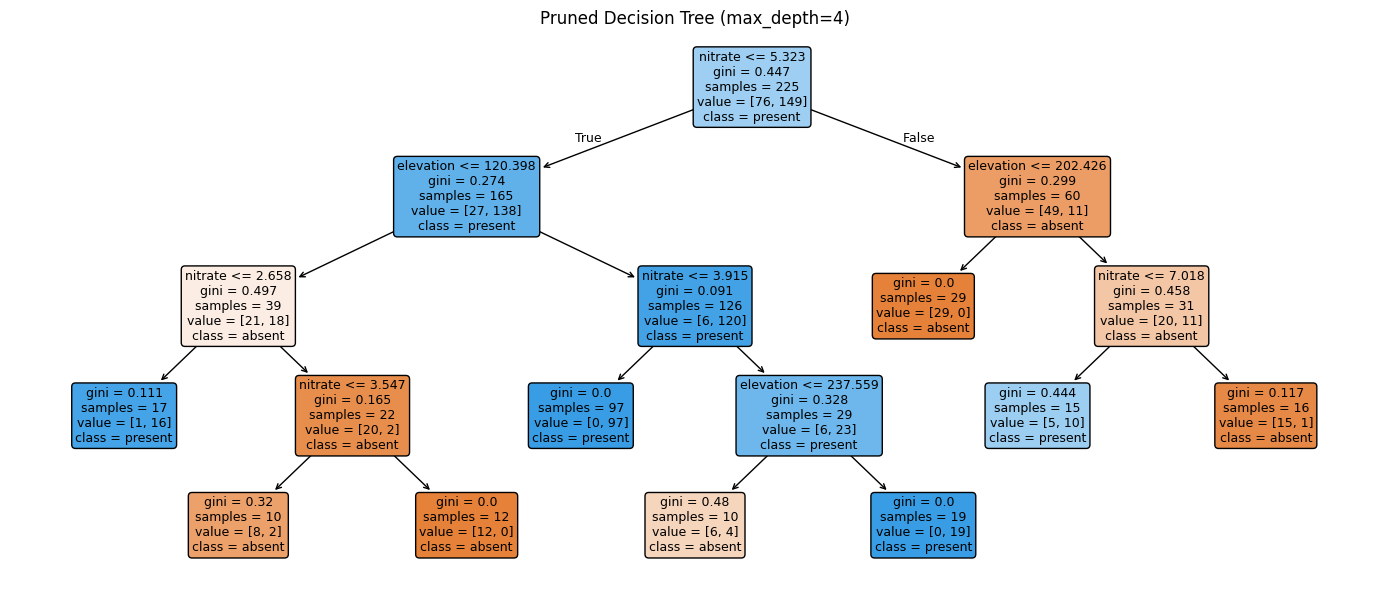

|--- nitrate <= 5.32
|   |--- elevation <= 120.40
|   |   |--- nitrate <= 2.66
|   |   |   |--- class: 1
|   |   |--- nitrate >  2.66
|   |   |   |--- nitrate <= 3.55
|   |   |   |   |--- class: 0
|   |   |   |--- nitrate >  3.55
|   |   |   |   |--- class: 0
|   |--- elevation >  120.40
|   |   |--- nitrate <= 3.91
|   |   |   |--- class: 1
|   |   |--- nitrate >  3.91
|   |   |   |--- elevation <= 237.56
|   |   |   |   |--- class: 0
|   |   |   |--- elevation >  237.56
|   |   |   |   |--- class: 1
|--- nitrate >  5.32
|   |--- elevation <= 202.43
|   |   |--- class: 0
|   |--- elevation >  202.43
|   |   |--- nitrate <= 7.02
|   |   |   |--- class: 1
|   |   |--- nitrate >  7.02
|   |   |   |--- class: 0



In [3]:
fig, ax = plt.subplots(figsize=(14,6))
plot_tree(tree_pruned, feature_names=feat_names, class_names=["absent","present"],
          filled=True, rounded=True, fontsize=9, ax=ax)
plt.title("Pruned Decision Tree (max_depth=4)")
plt.tight_layout(); plt.show()
print(export_text(tree_pruned, feature_names=feat_names))

---
## Cost-Complexity Pruning

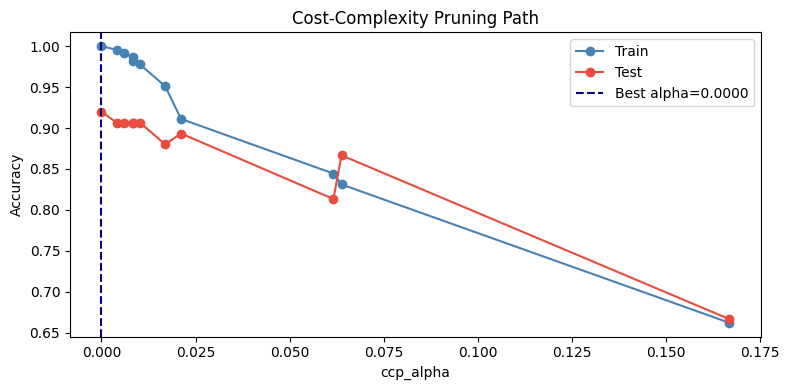

In [4]:
path = tree_full.cost_complexity_pruning_path(X_tr, y_tr)
alphas = path.ccp_alphas
tr_scores, te_scores = [], []
for a in alphas:
    t = DecisionTreeClassifier(ccp_alpha=a, random_state=42).fit(X_tr, y_tr)
    tr_scores.append(t.score(X_tr, y_tr))
    te_scores.append(t.score(X_te, y_te))
plt.figure(figsize=(8,4))
plt.plot(alphas, tr_scores, "o-", color="steelblue", label="Train", lw=1.5)
plt.plot(alphas, te_scores, "o-", color="#e74c3c",   label="Test",  lw=1.5)
best_a = alphas[np.argmax(te_scores)]
plt.axvline(best_a, color="navy", lw=1.5, linestyle="--", label=f"Best alpha={best_a:.4f}")
plt.xlabel("ccp_alpha"); plt.ylabel("Accuracy")
plt.title("Cost-Complexity Pruning Path"); plt.legend()
plt.tight_layout(); plt.show()

---
## Feature Importance and Confusion Matrix

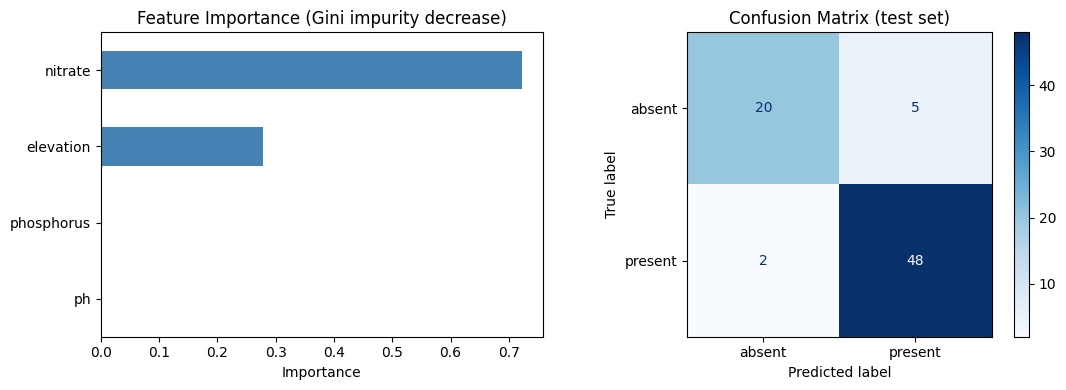

              precision    recall  f1-score   support

      absent       0.91      0.80      0.85        25
     present       0.91      0.96      0.93        50

    accuracy                           0.91        75
   macro avg       0.91      0.88      0.89        75
weighted avg       0.91      0.91      0.91        75



In [5]:
imp = pd.Series(tree_pruned.feature_importances_, index=feat_names).sort_values()
fig, axes = plt.subplots(1,2,figsize=(11,4))
imp.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Feature Importance (Gini impurity decrease)")
axes[0].set_xlabel("Importance")
ConfusionMatrixDisplay.from_estimator(tree_pruned, X_te, y_te,
    display_labels=["absent","present"], cmap="Blues", ax=axes[1])
axes[1].set_title("Confusion Matrix (test set)")
plt.tight_layout(); plt.show()
print(classification_report(y_te, tree_pruned.predict(X_te), target_names=["absent","present"]))

---

## Common Pitfalls

**1. Using a fully grown tree without pruning**  
An unpruned tree memorises training data, achieving near-perfect training accuracy while generalising poorly. Always limit `max_depth` or use cost-complexity pruning (`ccp_alpha`) selected by cross-validation.

**2. Interpreting Gini importance as a reliable feature ranking**  
Gini-based importance is biased toward high-cardinality and continuous features. It also reflects training data splits, not test set relevance. Use permutation importance on the test set for a less biased ranking.

**3. Not stratifying the train/test split for imbalanced classes**  
Without `stratify=label`, the split may produce very different class proportions in train and test. Always use `stratify=y` with `train_test_split`.

**4. Trusting single tree feature splits as stable**  
Decision trees are high-variance models. A slightly different sample can produce a completely different split at the root. Single trees are not reliable for feature selection; use random forests or permutation importance on held-out data.

**5. Using accuracy as the only metric for imbalanced classes**  
With 90% negative class prevalence, a model that predicts all-negative achieves 90% accuracy. Always report precision, recall, F1, and the confusion matrix alongside accuracy.

---
*python_methods_library - Samantha McGarrigle*